In [4]:
import pandas as pd
import zipfile
import io

# 1. Zip-in içindəki CSV-ni oxumaq üçün köməkçi funksiya
def read_csv_from_zip(zip_path, csv_name, skip=0):
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(csv_name) as f:
            return pd.read_csv(io.BytesIO(f.read()), skiprows=skip)

# 2. Fayl adlarını təyin edirik (Sənin arxivlərinin adları)
gdp_zip = 'API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107.zip'
inflation_zip = 'API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_84.zip'
unemployment_zip = 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.zip'
crisis_zip = 'archive (4).zip'

# 3. Məlumatları yükləyirik
# (Qeyd: CSV adları zip-in içindəki ilə eyni olmalıdır)
gdp_raw = read_csv_from_zip(gdp_zip, 'API_NY.GDP.MKTP.KD.ZG_DS2_en_csv_v2_107.csv', skip=4)
inf_raw = read_csv_from_zip(inflation_zip, 'API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_84.csv', skip=4)
uem_raw = read_csv_from_zip(unemployment_zip, 'API_SL.UEM.TOTL.ZS_DS2_en_csv_v2_93.csv', skip=4)
crisis_df = read_csv_from_zip(crisis_zip, 'global_crisis_data.csv')

# 4. Melding (Wide formatdan Long formata keçid)
def melt_data(df, value_name):
    year_cols = [col for col in df.columns if col.isdigit()]
    return df.melt(id_vars=['Country Name', 'Country Code'], 
                   value_vars=year_cols, var_name='Year', value_name=value_name)

gdp_clean = melt_data(gdp_raw, 'GDP_Growth')
inf_clean = melt_data(inf_raw, 'Inflation')
uem_clean = melt_data(uem_raw, 'Unemployment')

# 5. Birləşdirmə
gdp_clean['Year'] = gdp_clean['Year'].astype(int)
inf_clean['Year'] = inf_clean['Year'].astype(int)
uem_clean['Year'] = uem_clean['Year'].astype(int)

master_df = pd.merge(gdp_clean, inf_clean, on=['Country Name', 'Country Code', 'Year'], how='outer')
master_df = pd.merge(master_df, uem_clean, on=['Country Name', 'Country Code', 'Year'], how='outer')

# 6. Böhran datası ilə birləşdirmə
crisis_df = crisis_df.rename(columns={'iso3': 'Country Code', 'year': 'Year'})
crisis_df['Year'] = crisis_df['Year'].astype(int)
crisis_cols = ['Country Code', 'Year', 'banking_crisis', 'currency_crisis', 'debt_crisis', 'crisis_any']

final_df = pd.merge(master_df, crisis_df[crisis_cols], on=['Country Code', 'Year'], how='left')

# 7. Nəticə
final_df.to_csv('Global_Economic_Shock_Master.csv', index=False)
print("Uğurlu! 'Global_Economic_Shock_Master.csv' yaradıldı.")
print(final_df.head())

Uğurlu! 'Global_Economic_Shock_Master.csv' yaradıldı.
  Country Name Country Code  Year  GDP_Growth  Inflation  Unemployment  \
0  Afghanistan          AFG  1960         NaN        NaN           NaN   
1  Afghanistan          AFG  1961         NaN        NaN           NaN   
2  Afghanistan          AFG  1962         NaN        NaN           NaN   
3  Afghanistan          AFG  1963         NaN        NaN           NaN   
4  Afghanistan          AFG  1964         NaN        NaN           NaN   

   banking_crisis  currency_crisis  debt_crisis  crisis_any  
0             NaN              NaN          NaN         NaN  
1             NaN              NaN          NaN         NaN  
2             NaN              NaN          NaN         NaN  
3             NaN              NaN          NaN         NaN  
4             NaN              NaN          NaN         NaN  


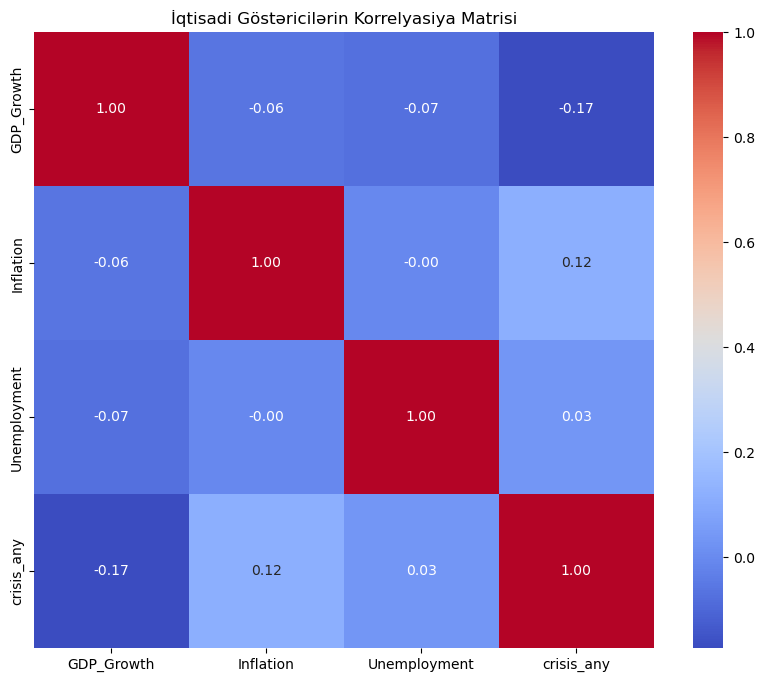

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Yalnız rəqəmsal sütunları seçirik
numeric_df = final_df[['GDP_Growth', 'Inflation', 'Unemployment', 'crisis_any']]

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('İqtisadi Göstəricilərin Korrelyasiya Matrisi')
plt.show()

Böhranın İqtisadiyyata Orta Təsiri:
            GDP_Growth  Inflation
crisis_any                       
0.0           4.315848   8.360591
1.0           2.537958  87.531596


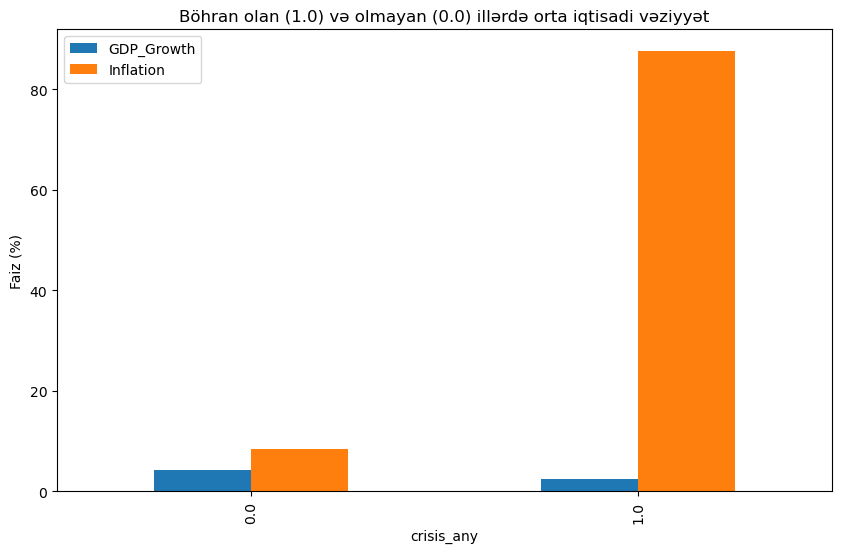

In [6]:
# Böhran olan və olmayan illərdə orta ÜDM və İnflyasiya
crisis_impact = final_df.groupby('crisis_any')[['GDP_Growth', 'Inflation']].mean()
print("Böhranın İqtisadiyyata Orta Təsiri:")
print(crisis_impact)

# Vizuallaşdırma
crisis_impact.plot(kind='bar', figsize=(10, 6))
plt.title('Böhran olan (1.0) və olmayan (0.0) illərdə orta iqtisadi vəziyyət')
plt.ylabel('Faiz (%)')
plt.show()

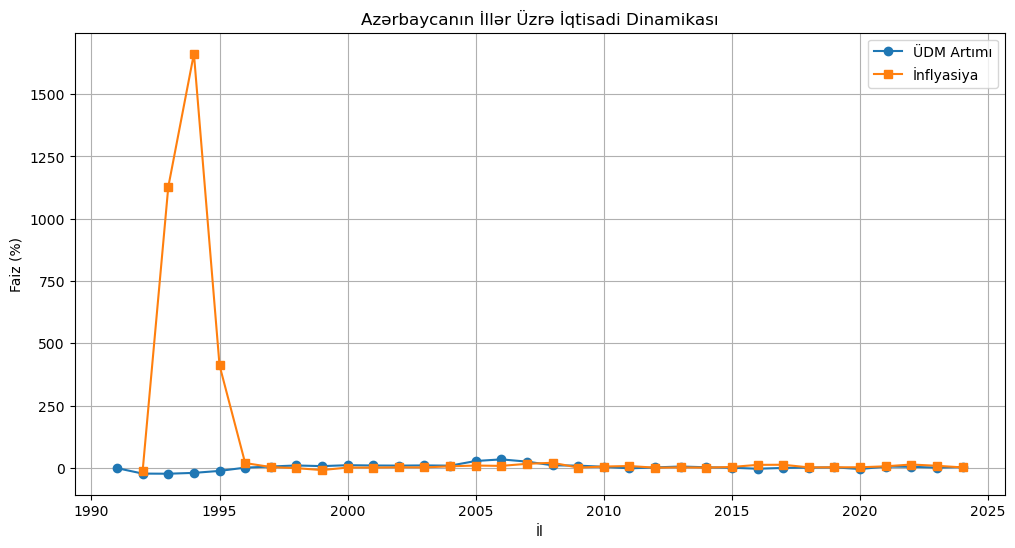

In [7]:
aze_data = final_df[final_df['Country Code'] == 'AZE']

plt.figure(figsize=(12, 6))
plt.plot(aze_data['Year'], aze_data['GDP_Growth'], label='ÜDM Artımı', marker='o')
plt.plot(aze_data['Year'], aze_data['Inflation'], label='İnflyasiya', marker='s')
plt.title('Azərbaycanın İllər Üzrə İqtisadi Dinamikası')
plt.xlabel('İl')
plt.ylabel('Faiz (%)')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# 'final_df' sənin bütün birləşmiş datandırsa:
final_df.to_csv('Global_Economic_Shock_Master.csv', index=False)
print("Fayl hazırlandı!")

Fayl hazırlandı!
